In [1]:
import tensorflow as tf

In [6]:
# Declaring constants in tensorflow
A = tf.constant([[1,2],[3,4]])
A
B = tf.constant([[5,6],[7,8]])

In [5]:
# # Declaring variables in tensorflow
V = tf.Variable([[1,2],[3,4]])
V

<tf.Variable 'Variable:0' shape=(2, 2) dtype=int32, numpy=
array([[1, 2],
       [3, 4]], dtype=int32)>

In [7]:
# concat two tensors
C = tf.concat([A,B],axis=1)
C

<tf.Tensor: shape=(2, 4), dtype=int32, numpy=
array([[1, 2, 5, 6],
       [3, 4, 7, 8]], dtype=int32)>

In [10]:
tensor = tf.zeros([3,3],dtype=tf.int32)
tensor

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]], dtype=int32)>

In [19]:
t = tf.zeros([3,4],dtype=tf.float32)
t

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)>

In [21]:
# reshaping tensor
reshape = tf.reshape(tensor=t,shape=[4,3])
reshape

<tf.Tensor: shape=(4, 3), dtype=float32, numpy=
array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)>

In [23]:
# transpose of a tensor
tr = tf.transpose(reshape)
tr

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)>

In [24]:
# Typecasting
ty = tf.cast(reshape,tf.int32)
ty

<tf.Tensor: shape=(4, 3), dtype=int32, numpy=
array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]], dtype=int32)>

In [26]:
# matrix multiplication
c = tf.constant([[1,2],[3,4]])
d = tf.constant([[5],
                [6]])
mult = tf.matmul(c,d)
mult

<tf.Tensor: shape=(2, 1), dtype=int32, numpy=
array([[17],
       [39]], dtype=int32)>

In [27]:
# identity matrix
S = tf.eye(num_rows=3,num_columns=3,dtype=tf.int16)
S

<tf.Tensor: shape=(3, 3), dtype=int16, numpy=
array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]], dtype=int16)>

Neural Networks With *Keras*

In [44]:
import numpy as np
from random import randint
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler

In [43]:
train_labels = []
train_samples = []

In [20]:
# 5% younger individuals who experienced side effects
for i in range(50):
    random_younger = randint(13, 64)
    train_samples.append(random_younger)
    train_labels.append(1)

    # 5% older individuals who did NOT experience side effects
    random_older = randint(65, 100)
    train_samples.append(random_older)
    train_labels.append(0)

# 95% younger individuals who did NOT experience side effects
for i in range(1000):
    random_younger = randint(13, 64)
    train_samples.append(random_younger)
    train_labels.append(0)

    # 95% older individuals who DID experience side effects
    random_older = randint(65, 100)
    train_samples.append(random_older)
    train_labels.append(1)

print(len(train_samples), train_samples[:5])
print(len(train_labels), train_labels[:5])

train_labels = np.array(train_labels)
train_samples = np.array(train_samples)

train_labels, train_samples = shuffle(train_labels, train_samples)

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_samples = scaler.fit_transform(train_samples.reshape(-1, 1))

print(scaled_train_samples[:5])


2100 [47, 96, 43, 84, 43]
2100 [1, 0, 1, 0, 1]
[[0.94252874]
 [0.75862069]
 [0.65517241]
 [0.37931034]
 [0.88505747]]


In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(units=16, input_shape=(1,), activation='relu'),
    Dense(units=32, activation='relu'),
    Dense(units=2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642 (2.51 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

Compile and Train

In [23]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    scaled_train_samples,
    train_labels,
    validation_split=0.1,
    batch_size=10,
    shuffle=True,
    epochs=30,
    verbose=2
)

Epoch 1/30
189/189 - 2s - 9ms/step - accuracy: 0.5656 - loss: 0.6739 - val_accuracy: 0.6381 - val_loss: 0.6584
Epoch 2/30
189/189 - 0s - 2ms/step - accuracy: 0.6487 - loss: 0.6385 - val_accuracy: 0.7000 - val_loss: 0.6253
Epoch 3/30
189/189 - 1s - 3ms/step - accuracy: 0.7392 - loss: 0.6027 - val_accuracy: 0.7286 - val_loss: 0.5926
Epoch 4/30
189/189 - 1s - 4ms/step - accuracy: 0.7825 - loss: 0.5664 - val_accuracy: 0.7857 - val_loss: 0.5597
Epoch 5/30
189/189 - 1s - 4ms/step - accuracy: 0.8079 - loss: 0.5314 - val_accuracy: 0.8429 - val_loss: 0.5287
Epoch 6/30
189/189 - 1s - 4ms/step - accuracy: 0.8349 - loss: 0.4973 - val_accuracy: 0.8524 - val_loss: 0.4983
Epoch 7/30
189/189 - 1s - 3ms/step - accuracy: 0.8513 - loss: 0.4645 - val_accuracy: 0.8571 - val_loss: 0.4697
Epoch 8/30
189/189 - 1s - 3ms/step - accuracy: 0.8688 - loss: 0.4340 - val_accuracy: 0.8667 - val_loss: 0.4438
Epoch 9/30
189/189 - 1s - 3ms/step - accuracy: 0.8741 - loss: 0.4060 - val_accuracy: 0.8714 - val_loss: 0.4206
E

In [24]:
test_labels = []
test_samples = []

In [37]:
test_labels = []
test_samples = []

# 5% younger individuals who experienced side effects
for i in range(10):
    random_younger = randint(13, 64)
    test_samples.append(random_younger)
    test_labels.append(1)

    # 5% older individuals who did NOT experience side effects
    random_older = randint(65, 100)
    test_samples.append(random_older)
    test_labels.append(0)

# 95% younger individuals who did NOT experience side effects
for i in range(200):
    random_younger = randint(13, 64)
    test_samples.append(random_younger)
    test_labels.append(0)

    # 95% older individuals who DID experience side effects
    random_older = randint(65, 100)
    test_samples.append(random_older)
    test_labels.append(1)

test_labels = np.array(test_labels)
test_samples = np.array(test_samples)

test_labels, test_samples = shuffle(test_labels, test_samples)

# Scaling
scaled_test_samples = scaler.transform(test_samples.reshape(-1, 1))

print(scaled_test_samples[:5])

[[0.16091954]
 [0.11494253]
 [0.45977011]
 [0.88505747]
 [0.59770115]]


In [38]:
predictions = model.predict(
    x=scaled_test_samples,
    batch_size=10,
    verbose=0
)

print(predictions[:5])

[[0.9752271  0.02477294]
 [0.9757274  0.02427254]
 [0.8108386  0.1891615 ]
 [0.03791355 0.9620865 ]
 [0.4357133  0.56428665]]


In [39]:
# rounding up predictions to get 0 or 1
rounded_predictions = np.argmax(predictions, axis=-1)

print(rounded_predictions[:5])

[0 0 0 1 1]


In [40]:
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true=test_labels, y_pred=rounded_predictions)

In [41]:
def plot_confusion_matrix(cm, classes,
                         normalize=False,
                         title='Confusion matrix',
                         cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization
[[196  14]
 [  9 201]]


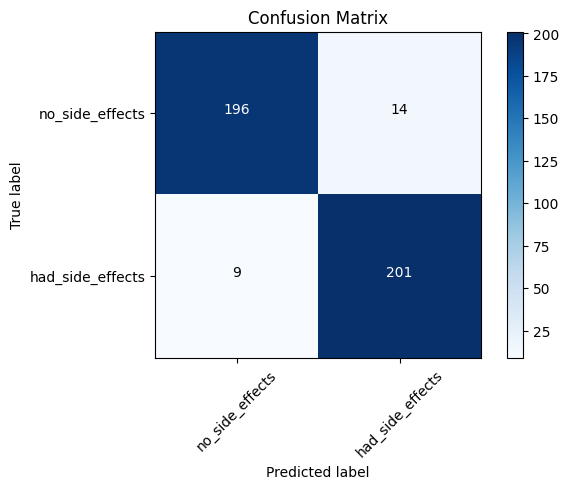

In [42]:
cm_plot_labels = ['no_side_effects', 'had_side_effects']

plot_confusion_matrix(
    cm=cm,
    classes=cm_plot_labels,
    title='Confusion Matrix'
)